# loading libraries

In [1]:
import pandas as pd
import numpy as np


# screping all the staion list form the berkely earth website

In [2]:
import requests
from bs4 import BeautifulSoup

url = "https://data.berkeleyearth.org/station-list/"

# 1. Fetch and parse the webpage
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# We'll store the results as a list of dictionaries
station_data = []

# 2. Find the table and loop through the rows
table = soup.find('table')

# Skip the header row using [1:]
for row in table.find_all('tr')[1:]:
    cols = row.find_all('td')

    # Check if we have at least 3 columns so we don't get an IndexError looking for the country
    if len(cols) >= 3:
        # The station name and link are in the first column (index 0)
        first_column = cols[0]

        # The country name is in the third column (index 2)
        country_text = cols[2].text.strip()

        # 3. Find the <a> tag inside the first column
        a_tag = first_column.find('a')

        # Make sure the <a> tag actually exists to avoid errors
        if a_tag:
            # Extract the visible text
            station_name = a_tag.text.strip()

            # Extract the href attribute (the link)
            station_link = a_tag['href']

            # Extract the station ID by splitting the link by '/' and grabbing the last item [-1]
            station_id = station_link.split('/')[-1]

            # Save everything to our list
            station_data.append({
                'station_name': station_name,
                'link': station_link,
                'station_id': station_id,
                'country_name': country_text  # <--- New key added here
            })

# Print the total count and the first 5 results to verify
print(f"Total stations found: {len(station_data)}\n")
for station in station_data[:5]:
    print(f"Name: {station['station_name']}")     # Fixed key name here
    print(f"ID: {station['station_id']}")
    print(f"Country: {station['country_name']}")  # Printed the country here
    print(f"Link: {station['link']}")
    print("-" * 20)

Total stations found: 500

Name: 
ID: 15146
Country: India
Link: https://data.berkeleyearth.org/stations/15146
--------------------
Name: (ODRY) RIYAN/ADEN PROTEC
ID: 165869
Country: Yemen
Link: https://data.berkeleyearth.org/stations/165869
--------------------
Name: (SOHAR) MAJIS
ID: 203
Country: Oman
Link: https://data.berkeleyearth.org/stations/203
--------------------
Name: ...
ID: 21895
Country: Russia
Link: https://data.berkeleyearth.org/stations/21895
--------------------
Name: ...
ID: 12357
Country: China
Link: https://data.berkeleyearth.org/stations/12357
--------------------


In [3]:
print(len(station_data))

500


# fetching individual station dataset

In [4]:
import pandas as pd
import requests
import time

data_url_template = "https://data.berkeleyearth.org/auto/Stations/TAVG/Text/{}-TAVG-Data.txt"

column_names = [
    "Year", "Month", "Raw_Data_Temperature", "Raw_Data_Anomaly",
    "QC_Failed", "Continuity_Breaks", "Adjusted_Data_Temperature",
    "Adjusted_Data_Anomaly", "Regional_Expectation_Temperature",
    "Regional_Expectation_Anomaly"
]

all_station_dfs = []

# Counters
success_count = 0
error_count = 0
null_station_ids = []   #  LIST instead of counter


for i, station in enumerate(station_data):
    print(f"\rProcessing: {i+1}/{len(station_data)}", end="")
    s_id = station['station_id']
    s_name = station['station_name']
    s_country = station['country_name']

    target_url = data_url_template.format(s_id)

    try:
        df_temp = pd.read_csv(
            target_url,
            sep=r"\s+",
            comment="%",
            names=column_names,
            engine="python"
        )

        #  Check empty or fully NaN
        if df_temp.empty or df_temp.isna().all().all():
            null_station_ids.append(s_id)   # store station id
            continue

        df_temp['station_name'] = s_name
        df_temp['station_id'] = s_id
        df_temp['country'] = s_country

        all_station_dfs.append(df_temp)

        success_count += 1

    except Exception as e:
        error_count += 1

# Final summary
print(f"\nFinished processing.")
print(f"Successfully fetched: {success_count}")
print(f"Null/Empty DataFrames skipped: {len(null_station_ids)}")  # ✅ length of list
print(f"Errors occurred: {error_count}")

Processing: 500/500
Finished processing.
Successfully fetched: 499
Null/Empty DataFrames skipped: 1
Errors occurred: 0


In [5]:
# manually chekcing whats wrong on null dataframes
if not null_station_ids:
    print("No null/empty stations found. No links generated.")
else:
    print(f"Generating links for {len(null_station_ids)} stations:\n")
    null_station_links = []
    for s_id in null_station_ids:
        link = data_url_template.format(s_id)
        null_station_links.append(link)
        print(link)


Generating links for 1 stations:

https://data.berkeleyearth.org/auto/Stations/TAVG/Text/38707-TAVG-Data.txt


In [6]:
# combinaing all dataframes into one single dataframe
if all_station_dfs:
    df = pd.concat(all_station_dfs, ignore_index=True)
    print("All data combined into one DataFrame.")

All data combined into one DataFrame.


# adding continent column

In [7]:
pip install pycountry_convert

In [31]:
import pandas as pd
import pycountry_convert as pc
def get_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_code)

        continent_map = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "North America",
            "SA": "South America",
            "OC": "Oceania",
            "AN": "Antarctica"
        }

        return continent_map[continent_code]
    except:
        return "Unknown"

df["continent"] = df["country"].apply(get_continent)

print(df.head())

   Year  Month  Raw_Data_Temperature  Raw_Data_Anomaly  QC_Failed  \
0  1926      6                  29.7            -0.357        0.0   
1  1926      7                  29.7            -0.357        0.0   
2  1926      8                  29.7            -0.357        0.0   
3  1926      9                  29.7            -0.357        0.0   
4  1926     10                  29.7            -0.357        0.0   

   Continuity_Breaks  Adjusted_Data_Temperature  Adjusted_Data_Anomaly  \
0                0.0                      30.56                  0.504   
1                0.0                      30.56                  0.504   
2                0.0                      30.56                  0.504   
3                0.0                      30.56                  0.504   
4                0.0                      30.56                  0.504   

   Regional_Expectation_Temperature  Regional_Expectation_Anomaly  \
0                            30.171                         0.985   
1 

# downlading the combined(all station)  dataset

In [32]:
import os
from google.colab import files
csv_filename = "berkeley_earth_dataset.csv"
#Save the DataFrame to the server
df.to_csv(csv_filename, index=False, encoding='utf-8')
# Trigger the download to your local computer
files.download(csv_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Wait a moment and delete the file from the server
# Note: In Colab, files.download is asynchronous, but the server handles the delete request smoothly.
if os.path.exists(csv_filename):
    os.remove(csv_filename)
    print(f"File '{csv_filename}' has been deleted from the server.")

File 'berkeley_earth_dataset.csv' has been deleted from the server.


# counting null values

In [11]:
# Count NaNs per column
df.isna().sum()

,0
Year,0
Month,0
Raw_Data_Temperature,49233
Raw_Data_Anomaly,49233
QC_Failed,49233
Continuity_Breaks,49233
Adjusted_Data_Temperature,62989
Adjusted_Data_Anomaly,62989
Regional_Expectation_Temperature,244
Regional_Expectation_Anomaly,244


# finding optimised way to replace null/nan values

$$
\begin{array}{c}
\mathbf{START} \\
\downarrow \\
\text{Remove Original Missing Values} \\
\downarrow \\
\text{Save Ground Truth } (Y_{true}) \\
\downarrow \\
\text{Create 20\% Fake Missing Values} \\
\downarrow \\
\begin{array}{c|c|c}
\text{Interpolation} & \text{Mean Fill} & \text{Forward Fill}
\end{array} \\
\downarrow \\
\text{Calculate MAE Error} \\
\downarrow \\
\text{Choose Method With Lowest MAE} \\
\downarrow \\
\mathbf{END}
\end{array}
$$

In [12]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

# Assuming 'df' is already loaded with your Berkeley Earth data.
# 1. Make a copy of the original dataset
df_new = df.copy()

# 2. Use the correct temperature column based on your dataset headers
col = "Raw_Data_Temperature"

# 3. Drop existing null values to create Ground Truth
df_clean = df_new.dropna(subset=[col]).reset_index(drop=True)

ground_truth = df_clean[col].copy()

# 4. Create Fake Missing Values (Mask 20%)
np.random.seed(42)
mask = np.random.rand(len(df_clean)) < 0.2

df_test = df_clean.copy()
df_test.loc[mask, col] = np.nan

# 5. Apply Imputation Methods
methods = {
    "Interpolation": df_test[col].interpolate(method='linear'),
    "Global Mean Fill": df_test[col].fillna(df_test[col].mean()),
    # Grouped Mean: Calculate mean per station, then fill
    "Station Group Mean": df_test.groupby('station_id')[col].transform(lambda x: x.fillna(x.mean())),
    "Forward Fill": df_test[col].ffill().bfill()
}

# 6. Compare with Ground Truth using MAE
results = []

for name, imputed_series in methods.items():
    mae = mean_absolute_error(ground_truth[mask], imputed_series[mask])
    results.append({"Method": name, "MAE": round(mae, 4)})

# 7. Display results
results_df = pd.DataFrame(results).sort_values(by="MAE")

print("--- Imputation Performance ---")
print(results_df)

best = results_df.iloc[0]['Method']
print(f"\nRecommended Method: {best}")

--- Imputation Performance ---
               Method      MAE
0       Interpolation   2.1135
3        Forward Fill   4.5724
2  Station Group Mean   6.6376
1    Global Mean Fill  10.0549

Recommended Method: Interpolation


# handling null/nan values

In [13]:
import pandas as pd

# Identify the columns to interpolate (all except the last 3)
# df.columns[:-4] selects everything up to the last four names
cols_to_fix = df.columns[:-4]

# Apply interpolation ONLY to those columns
# limit_direction='both' ensures that if the first or last rows are null,
# it handles them by looking forward/backward.
df[cols_to_fix] = df[cols_to_fix].interpolate(method='linear', limit_direction='both')

# Check if any Nulls remain in the temperature columns
print("Null values remaining per column:")
print(df[cols_to_fix].isnull().sum())

# Verify the last 4 columns are untouched
print("\nLast 4 columns (Metadata):")
print(df.columns[-4:].tolist())

Null values remaining per column:
Year                                0
Month                               0
Raw_Data_Temperature                0
Raw_Data_Anomaly                    0
QC_Failed                           0
Continuity_Breaks                   0
Adjusted_Data_Temperature           0
Adjusted_Data_Anomaly               0
Regional_Expectation_Temperature    0
Regional_Expectation_Anomaly        0
dtype: int64

Last 4 columns (Metadata):
['station_name', 'station_id', 'country', 'continent']


# g1-Countries with the Highest Average Temperature Rise

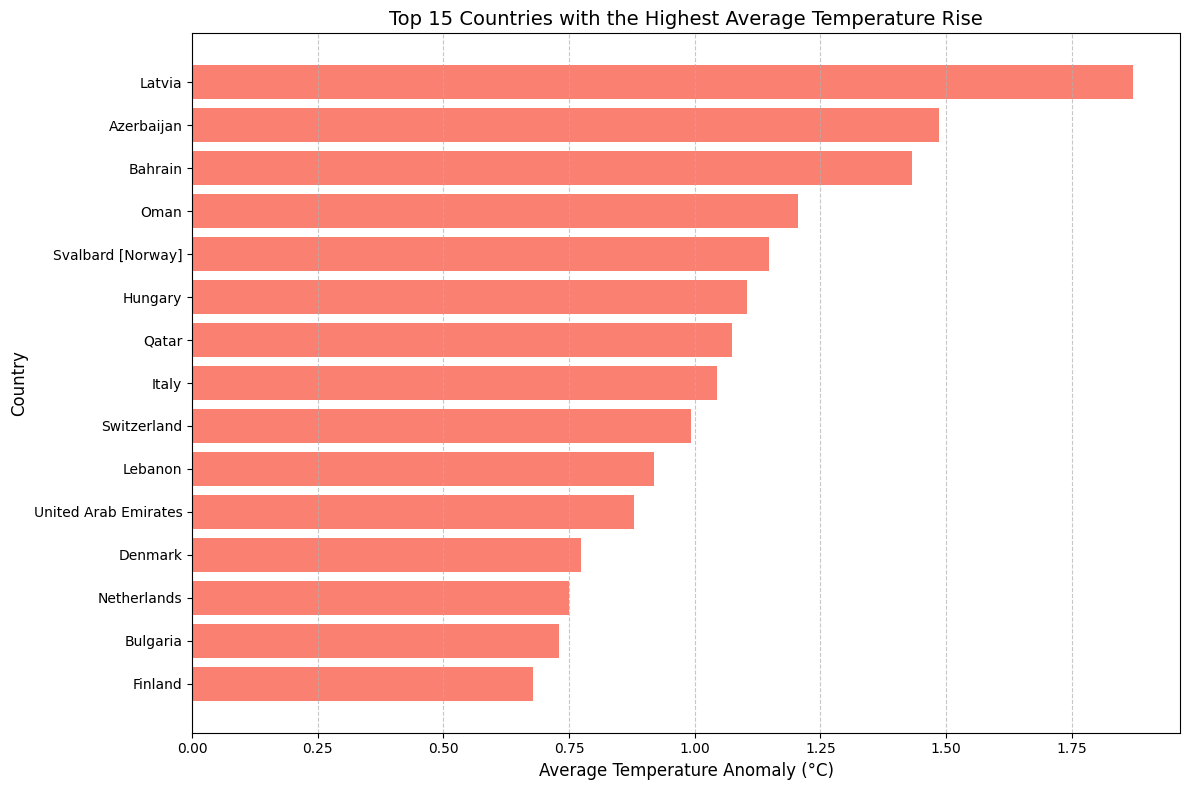

                 country  Adjusted_Data_Anomaly
47                Latvia               1.871954
5             Azerbaijan               1.486785
7                Bahrain               1.431726
58                  Oman               1.204650
72     Svalbard [Norway]               1.148250
32               Hungary               1.104391
65                 Qatar               1.073825
39                 Italy               1.043984
74           Switzerland               0.992502
48               Lebanon               0.919751
79  United Arab Emirates               0.878580
20               Denmark               0.773481
54           Netherlands               0.749873
9               Bulgaria               0.730843
25               Finland               0.677667


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
# Group by country and calculate the mean of 'Adjusted_Data_Anomaly'
# 'Adjusted_Data_Anomaly' represents the temperature rise relative to a baseline.
country_avg_temp = df.groupby('country')['Adjusted_Data_Anomaly'].mean().reset_index()

# Sort and Truncate
# Sort by the average anomaly in descending order and take the top 15
top_15_countries = country_avg_temp.sort_values(by='Adjusted_Data_Anomaly', ascending=False).head(15)

# Visualisation
plt.figure(figsize=(12, 8))

# Create a horizontal bar chart
plt.barh(top_15_countries['country'], top_15_countries['Adjusted_Data_Anomaly'], color='salmon')

# Adding labels and title
plt.xlabel('Average Temperature Anomaly (°C)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Top 15 Countries with the Highest Average Temperature Rise', fontsize=14)

# Invert y-axis so the highest value is at the top
plt.gca().invert_yaxis()

# Add a grid for easier reading of values
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Save or show the plot
plt.savefig('highest_temp_rise_chart.png')
plt.show()

# Optional: Print the resulting data for verification
print(top_15_countries)

# g2-Countries with the Lowest Average Temperature Rise

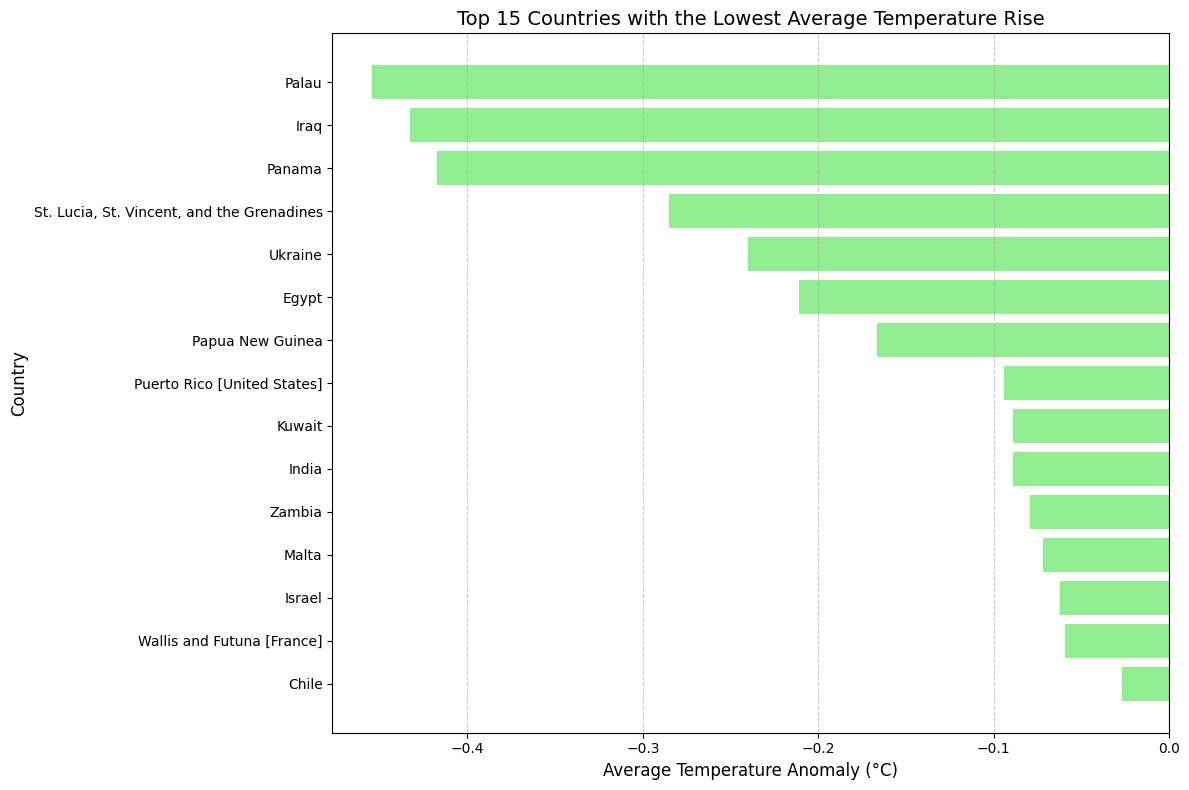

                                       country  Adjusted_Data_Anomaly
59                                       Palau              -0.454227
37                                        Iraq              -0.432856
60                                      Panama              -0.417101
70  St. Lucia, St. Vincent, and the Grenadines              -0.285113
78                                     Ukraine              -0.240309
21                                       Egypt              -0.210679
61                            Papua New Guinea              -0.166313
64                 Puerto Rico [United States]              -0.094067
45                                      Kuwait              -0.089189
34                                       India              -0.088735
86                                      Zambia              -0.079446
50                                       Malta              -0.072082
38                                      Israel              -0.062122
84                  

In [15]:
# Sort and Truncate
# Sort in ascending order (lowest values first) and take the top 15
lowest_15_countries = country_avg_temp.sort_values(by='Adjusted_Data_Anomaly', ascending=True).head(15)

# 5. Visualisation
plt.figure(figsize=(12, 8))

# Create a horizontal bar chart with a different color (light green)
plt.barh(lowest_15_countries['country'], lowest_15_countries['Adjusted_Data_Anomaly'], color='lightgreen')

# Adding labels and title
plt.xlabel('Average Temperature Anomaly (°C)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Top 15 Countries with the Lowest Average Temperature Rise', fontsize=14)

# Invert y-axis so the lowest value is at the top
plt.gca().invert_yaxis()

# Add a grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save the plot
plt.savefig('lowest_temp_rise_chart.png')
plt.show()

# Print the top 15 data for reference
print(lowest_15_countries)

# g3- Global Average Temperature Distribution (Histogram)

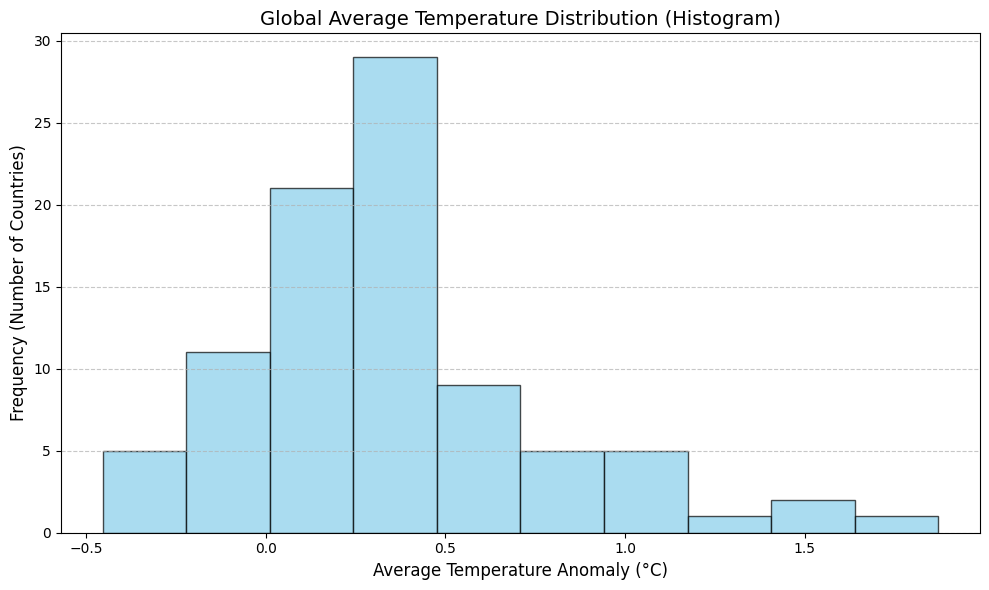

      country   Average
0     Algeria  0.610057
1  Antarctica  0.431687
2   Argentina  0.343903
3   Australia  0.103957
4     Austria  0.156519


In [16]:
# Group by country and calculate the average 'Adjusted_Data_Anomaly'
# We rename this result to 'Average' as per your requirements
df_can = df.groupby('country')['Adjusted_Data_Anomaly'].mean().reset_index()
df_can.rename(columns={'Adjusted_Data_Anomaly': 'Average'}, inplace=True)

# 4. Generate the Visualisation (Histogram)
plt.figure(figsize=(10, 6))

# Plot the distribution using 10 bins
plt.hist(df_can['Average'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)

# Adding labels and title
plt.title('Global Average Temperature Distribution (Histogram)', fontsize=14)
plt.xlabel('Average Temperature Anomaly (°C)', fontsize=12)
plt.ylabel('Frequency (Number of Countries)', fontsize=12)

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent clipping
plt.tight_layout()

# Save the plot
plt.savefig('global_temp_distribution_histogram.png')

# Display the plot
plt.show()

# Optional: Print the first few rows of df_can to verify
print(df_can.head())

# g4- Temperature Comparison between 4 Periods

/tmp/ipykernel_11318/2571240539.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_data = df_clean.groupby(['continent', 'Period_Label'])['Adjusted_Data_Anomaly'].mean().unstack()


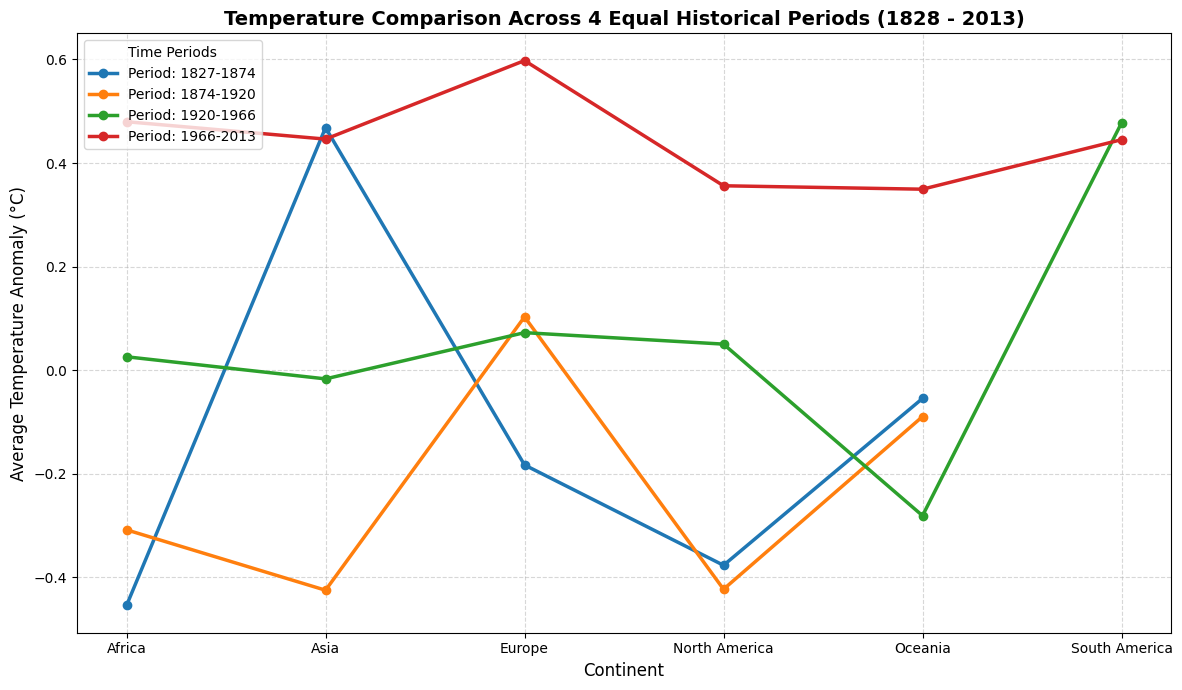

In [36]:
# Data Cleaning
# Remove 'Unknown' continent and rows with missing anomalies
df_clean = df[(df['continent'] != 'Unknown') & (df['Adjusted_Data_Anomaly'].notna())].copy()

# Create 4 Equal Periods
# We use the range between the lowest and highest years to split into 4 equal bins
df_clean['Period'] = pd.cut(df_clean['Year'], bins=4)

# Format the period labels (e.g., '1827-1874') for the graph legend
df_clean['Period_Label'] = df_clean['Period'].apply(lambda x: f"{int(x.left)}-{int(x.right)}")

# Calculate Average Anomaly per Continent and Period
# We aggregate the mean temperature change (anomaly) across these 4 chunks of time
period_data = df_clean.groupby(['continent', 'Period_Label'])['Adjusted_Data_Anomaly'].mean().unstack()

# Reorder continents for a consistent x-axis
continent_order = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']
period_data = period_data.reindex(continent_order)

# Visualisation (Line Graph)
plt.figure(figsize=(12, 7))

# Plot each of the 4 periods as a different colored line
for period in period_data.columns:
    plt.plot(period_data.index, period_data[period], marker='o', label=f"Period: {period}", linewidth=2.5)

# Styling the chart
plt.title('Temperature Comparison Across 4 Equal Historical Periods (1828 - 2013)', fontsize=14, fontweight='bold')
plt.xlabel('Continent', fontsize=12)
plt.ylabel('Average Temperature Anomaly (°C)', fontsize=12)
plt.legend(title='Time Periods', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Display
plt.savefig('four_periods_temperature_comparison.png')
plt.show()

g5- temperature rise accross continents

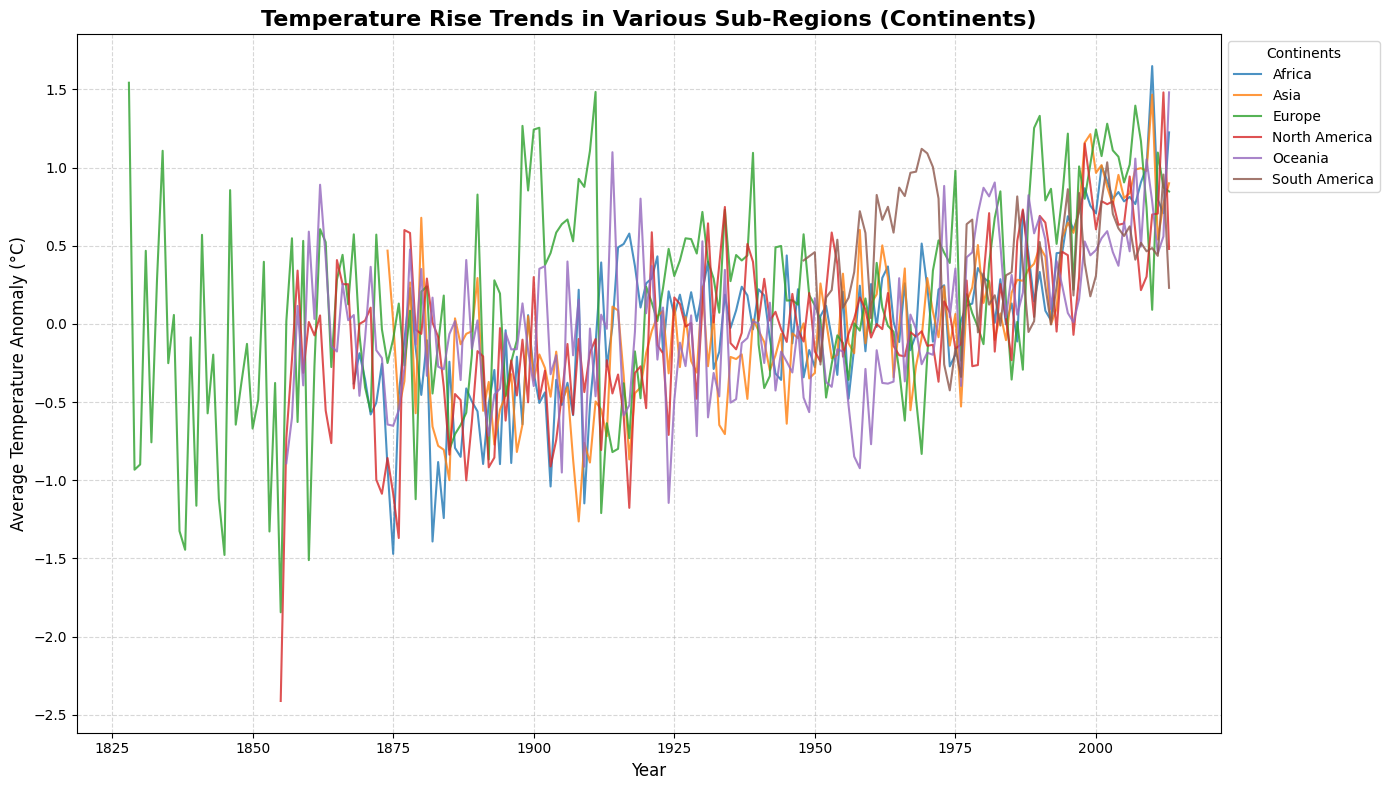

In [38]:
# Data Cleaning
# Remove 'Unknown' continent and rows with missing temperature anomalies
df_clean = df[(df['continent'] != 'Unknown') & (df['Adjusted_Data_Anomaly'].notna())].copy()

# Process the Data
# Group by 'Year' and 'continent' and calculate the mean temperature anomaly
# This gives us a yearly trend line for each continent.
yearly_continent_trends = df_clean.groupby(['Year', 'continent'])['Adjusted_Data_Anomaly'].mean().unstack()

# Generate the Line Graph
plt.figure(figsize=(14, 8))

# Define the continents to be plotted
continents_to_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

# Plot each continent's annual trend
for continent in continents_to_plot:
    if continent in yearly_continent_trends.columns:
        plt.plot(yearly_continent_trends.index, yearly_continent_trends[continent],
                 label=continent, alpha=0.8, linewidth=1.5)

# Styling the graph
plt.title('Temperature Rise Trends in Various Sub-Regions (Continents)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature Anomaly (°C)', fontsize=12)
plt.legend(title='Continents', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the plot and show
plt.savefig('temperature_rise_trends_continents.png')
plt.show()

# Export the trend data for reference
yearly_continent_trends.to_csv('yearly_continent_temp_trends.csv')

# g6- Warming Stripes: Regional Temperature Departure from Baseline

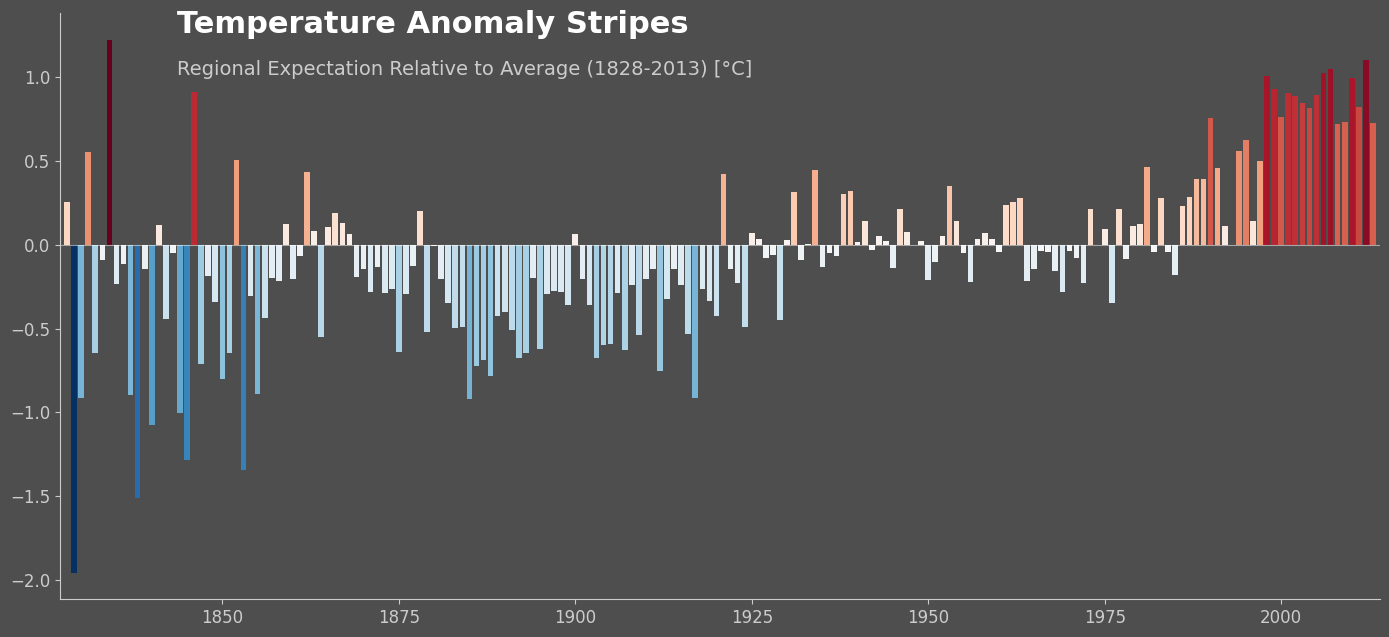

In [39]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

# --- 1. PREPARE DATA ---

# In your dataset, the anomaly column is 'Regional_Expectation_Anomaly'
# We need to group by Year to get the mean annual anomaly
annual_temp = df.groupby('Year')['Regional_Expectation_Anomaly'].mean().reset_index()
annual_temp = annual_temp.rename(columns={'Regional_Expectation_Anomaly': 'Anomaly'})

# --- 2. VISUALIZATION ---

bg_color = '#4e4e4e'
fig, ax = plt.subplots(figsize=(14, 7), facecolor=bg_color)
ax.set_facecolor(bg_color)

# Colormap (blue=cold, red=warm)
cmap = plt.get_cmap('RdBu_r')

# Normalize around zero to ensure 0.0 is the neutral color
norm = mcolors.TwoSlopeNorm(
    vmin=annual_temp['Anomaly'].min(),
    vcenter=0,
    vmax=annual_temp['Anomaly'].max()
)

# Plot bars
ax.bar(
    annual_temp['Year'],
    annual_temp['Anomaly'],
    width=0.8, # Small gap between bars looks cleaner for this data
    color=cmap(norm(annual_temp['Anomaly']))
)

# --- 3. STYLING ---

baseline_start = int(annual_temp['Year'].min())
baseline_end = int(annual_temp['Year'].max())

# Add Titles
fig.text(0.13, 0.90, 'Temperature Anomaly Stripes', color='white', fontsize=22, fontweight='bold')
fig.text(0.13, 0.84,
         f'Regional Expectation Relative to Average ({baseline_start}-{baseline_end}) [°C]',
         color='#cccccc', fontsize=14)

# Clean up spines (borders)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')

# Set ticks
ax.tick_params(axis='x', colors='#cccccc', labelsize=12)
ax.tick_params(axis='y', colors='#cccccc', labelsize=12)

ax.set_xlim(annual_temp['Year'].min() - 1, annual_temp['Year'].max() + 1)

# Horizontal line at 0 for reference
ax.axhline(0, color='white', linewidth=0.8, alpha=0.5)

ax.grid(False)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# g7-National Temperature Evolution (1828–2013): A Multi-Country Time-Series
*This interactive line chart allows you to toggle individual countries in the legend to isolate and view their specific temperature trends.*

In [41]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# DATA PREPARATION ---

# Note: We aggregate by Year AND Country to get the mean temperature per country-year.
# We must use 'Regional_Expectation_Anomaly' or the combined stations average because
# absolute temperatures vary too much by latitude to be plotted together effectively.

# Step A: Group by Year and Country to get the national average per year
# Check your specific column name in df, assuming 'Regional_Expectation_Temperature'
temp_col = 'Regional_Expectation_Temperature'

# Ensure year is sorted for correct line drawing
df_sorted = df.sort_values(['country', 'Year'])

# Group the data
annual_country_temp = df_sorted.groupby(['Year', 'country'])[temp_col].mean().reset_index()

# Step B: Ensure data is cleaned (remove NaNs) for clean lines
annual_country_temp_clean = annual_country_temp.dropna().copy()

# Rename columns for cleaner labels in the interactive chart
annual_country_temp_clean.columns = ['Year', 'Country', 'Mean_Annual_Temp']

# CREATE INTERACTIVE CHART ---

fig = px.line(
    annual_country_temp_clean,
    x="Year",
    y="Mean_Annual_Temp",
    color="Country",  # This creates one unique color line per country
    title="Regional Mean Annual Temperature Over Time",
    markers=True     # Add points to the lines for clearer hover interactions
)

# CUSTOMIZE VISUALS ---

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Mean Annual Temperature (°C)",
    hovermode="closest", # Hover shows the data for the specific point touched
    template="plotly_dark", # Use a dark background to match your aesthetic preference
    legend_title_text='Countries'
)

# Set the x-axis to show years precisely
fig.update_xaxes(tickmode='auto', nticks=30, tickformat='d')

# Configure Tooltip (Hover) behavior
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Mean Annual Temperature (°C)",
    hovermode="closest",
    template="plotly_dark",
    legend=dict(
        # 'toggleothers' makes a single click hide everything else
        # and show ONLY the selected item.
        itemclick="toggleothers",

        # 'toggle' makes a double-click act like the normal single-click
        itemdoubleclick="toggle"
    )
)

fig.show()